In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

In [15]:
file_path = "..\processed\kpi_daily_2022.csv"
df_daily = pd.read_csv(
    file_path,
    parse_dates=['tpep_pickup_datetime'],
    index_col='tpep_pickup_datetime'
)

print(df_daily.head())

                         revenue  total_distance  total_duration_minutes  \
tpep_pickup_datetime                                                       
2022-01-01             910426.99       170264.99           550053.733333   
2022-01-02             938472.15       184572.81           547640.183333   
2022-01-03            1034025.41       193820.11           612510.066667   
2022-01-04            1005544.86       179946.02           628259.733333   
2022-01-05             977550.50       171541.95           627180.716667   

                      total_passengers  total_tips  total_fare_revenue  \
tpep_pickup_datetime                                                     
2022-01-01                     70500.0   108746.95           631846.36   
2022-01-02                     63677.0   114743.57           658157.65   
2022-01-03                     72773.0   124713.27           705980.21   
2022-01-04                     74284.0   120919.29           681009.18   
2022-01-05             

In [16]:
# Tạo đặc trưng thời gian
df_daily['trips_last_week'] = df_daily['total_trips'].shift(7) # Số chuyến 7 ngày trước
df_daily['trips_2_weeks_ago'] = df_daily['total_trips'].shift(14) # Số chuyến 14 ngày trước
df_daily['trips_3_weeks_ago'] = df_daily['total_trips'].shift(21) # Số chuyến 21 ngày trước

print(df_daily[['total_trips', 'trips_last_week', 'trips_3_weeks_ago']].head(25))

                      total_trips  trips_last_week  trips_3_weeks_ago
tpep_pickup_datetime                                                 
2022-01-01                  43415              NaN                NaN
2022-01-02                  40595              NaN                NaN
2022-01-03                  48750              NaN                NaN
2022-01-04                  50445              NaN                NaN
2022-01-05                  50486              NaN                NaN
2022-01-06                  54305              NaN                NaN
2022-01-07                  48767              NaN                NaN
2022-01-08                  57506          43415.0                NaN
2022-01-09                  44009          40595.0                NaN
2022-01-10                  49463          48750.0                NaN
2022-01-11                  51824          50445.0                NaN
2022-01-12                  54367          50486.0                NaN
2022-01-13          

In [17]:
# Dự đoán nhu cầu 
feature_cols = ['trips_last_week', 'trips_2_weeks_ago', 'trips_3_weeks_ago'] # Gộp các đặc trưng lại 1 danh sách để thực hiện tính toán trung bình

df_daily['prediction'] = df_daily[feature_cols].mean(axis=1) # Tính toán 

print(df_daily[['total_trips'] + feature_cols + ['prediction']].head(25))

                      total_trips  trips_last_week  trips_2_weeks_ago  \
tpep_pickup_datetime                                                    
2022-01-01                  43415              NaN                NaN   
2022-01-02                  40595              NaN                NaN   
2022-01-03                  48750              NaN                NaN   
2022-01-04                  50445              NaN                NaN   
2022-01-05                  50486              NaN                NaN   
2022-01-06                  54305              NaN                NaN   
2022-01-07                  48767              NaN                NaN   
2022-01-08                  57506          43415.0                NaN   
2022-01-09                  44009          40595.0                NaN   
2022-01-10                  49463          48750.0                NaN   
2022-01-11                  51824          50445.0                NaN   
2022-01-12                  54367          50486.0 

In [18]:
# Đánh giá sai số
df_model = df_daily.dropna(subset=['prediction']).copy() # Loại bỏ các dòng có giá trị NaN trong cột 'prediction'

mae = mean_absolute_error(df_model['total_trips'], df_model['prediction'])
mean_trips = df_model['total_trips'].mean()
mape = (mae / mean_trips) * 100

print(f"Dữ liệu đánh giá từ: {df_model.index.min().date()} đến {df_model.index.max().date()}")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:,.0f} chuyến")
print(f"Tỷ lệ sai số (MAPE): {mape:.2f}%")



Dữ liệu đánh giá từ: 2022-01-08 đến 2022-12-31
Sai số tuyệt đối trung bình (MAE): 5,951 chuyến
Tỷ lệ sai số (MAPE): 8.01%


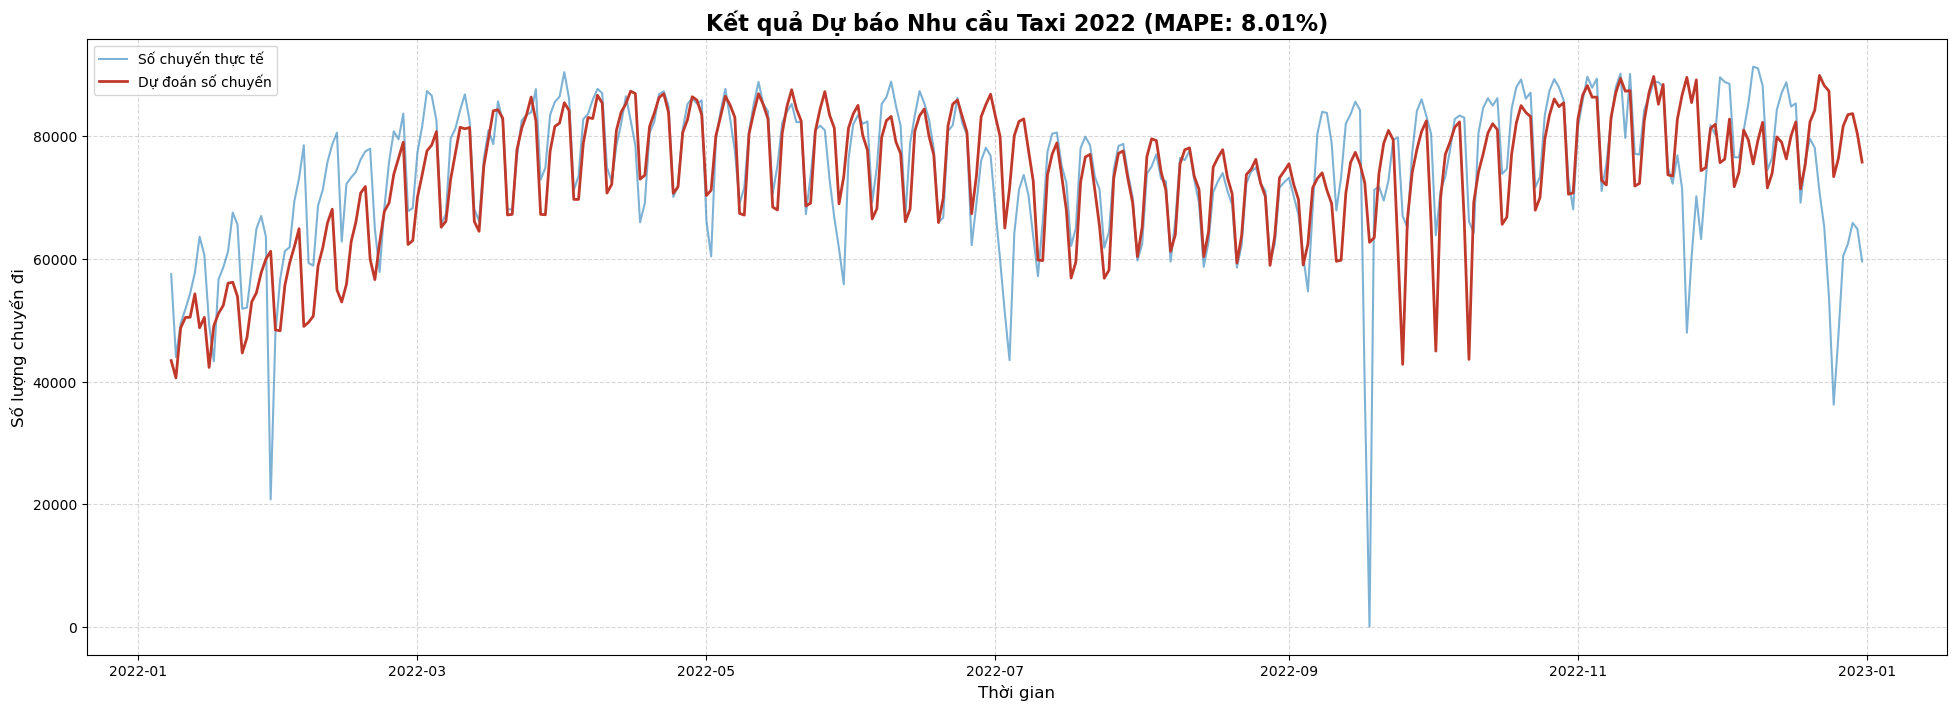

In [20]:
# Vẽ biểu đồ so sánh
plt.figure(figsize=(24, 8))

sns.lineplot(
    data = df_model,
    x = df_model.index,
    y = 'total_trips',
    label = 'Số chuyến thực tế',
    color = '#2980b9',
    alpha = 0.6
)

sns.lineplot(
    data = df_model,
    x = df_model.index,
    y = 'prediction',
    label = 'Dự đoán số chuyến',
    color = '#c0392b',
    linewidth = 2
)


plt.title(f'Kết quả Dự báo Nhu cầu Taxi 2022 (MAPE: {mape:.2f}%)', fontsize=16, fontweight='bold')
plt.ylabel('Số lượng chuyến đi', fontsize=12)
plt.xlabel('Thời gian', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [19]:
# Tính sai số cho từng ngày
df_model['AE'] = (df_model['total_trips'] - df_model['prediction']).abs() # Sai số tuyệt đối (số chuyến)
df_model['APE'] = (df_model['AE'] / df_model['total_trips']) * 100       # Phần trăm sai số (%)

# Làm tròn số 
df_detail = df_model[['total_trips', 'prediction', 'AE', 'APE']].copy()
df_detail['prediction'] = df_detail['prediction'].round(0).astype(int)
df_detail['AE'] = df_detail['AE'].round(0).astype(int)
df_detail['APE'] = df_detail['APE'].round(2)


df_detail.columns = ['Thực tế', 'Dự báo', 'Sai số (chuyến)', 'Sai số (%)']

print(df_detail.head(31))


                      Thực tế  Dự báo  Sai số (chuyến)  Sai số (%)
tpep_pickup_datetime                                              
2022-01-08              57506   43415            14091       24.50
2022-01-09              44009   40595             3414        7.76
2022-01-10              49463   48750              713        1.44
2022-01-11              51824   50445             1379        2.66
2022-01-12              54367   50486             3881        7.14
2022-01-13              57751   54305             3446        5.97
2022-01-14              63617   48767            14850       23.34
2022-01-15              60624   50460            10164       16.76
2022-01-16              49369   42302             7067       14.31
2022-01-17              43313   49106             5794       13.38
2022-01-18              56682   51134             5548        9.79
2022-01-19              58621   52426             6194       10.57
2022-01-20              61192   56028             5164        

In [21]:
# Những ngày có sai số cao nhất
df_detail.sort_values(by='Sai số (%)', ascending=False).head(30)

,Thực tế,Dự báo,Sai số (chuyến),Sai số (%)
tpep_pickup_datetime,,,,
2022-09-18,38,62699,62661,164898.25
2022-01-29,20788,61232,40444,194.55
2022-12-25,36237,73398,37161,102.55
2022-09-17,38527,72389,33862,87.89
2022-11-24,47965,89588,41623,86.78
2022-07-04,43491,71488,27997,64.37
2022-12-24,53775,87367,33592,62.47
2022-12-26,47506,76374,28868,60.77
2022-11-25,60288,85476,25188,41.78


In [22]:
file_path_error = "..\processed\yellow_tripdata_2022-09.parquet"
df_error = pd.read_parquet(file_path_error)
df_error_day = df_error[df_error['tpep_pickup_datetime'].dt.date == pd.to_datetime('2022-09-18').date()]
print(len(df_error_day))
print(df_error_day.head())

4229
         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
1770616         1  2022-09-18 15:00:57   2022-09-18 15:29:03              1.0   
1770617         1  2022-09-18 15:42:14   2022-09-18 16:13:16              1.0   
1770618         1  2022-09-18 16:34:11   2022-09-18 16:50:13              1.0   
1770619         1  2022-09-18 16:54:34   2022-09-18 17:03:52              1.0   
1770620         1  2022-09-18 17:37:30   2022-09-18 17:41:45              1.0   

         trip_distance  RatecodeID store_and_fwd_flag  payment_type  \
1770616            6.0         1.0                  Y             1   
1770617            4.4         1.0                  Y             1   
1770618            2.1         1.0                  Y             1   
1770619            1.7         1.0                  Y             1   
1770620            0.4         1.0                  N             1   

         fare_amount  extra  ...  tolls_amount  improvement_surcharge  \
1770616 

In [ ]:
# Sửa dữ liệu lỗi
df_cp_daily = df_daily.copy()
val_last_week_1 = df_cp_daily.loc['2022-09-11', 'total_trips']
val_last_week_2 = df_cp_daily.loc['2022-09-10', 'total_trips']
df_cp_daily.loc['2022-09-18', 'total_trips'] = val_last_week_1 # Sửa lại giá trị cho ngày 18/09/2022 bằng giá trị của ngày 11/09/2022
df_cp_daily.loc['2022-09-17', 'total_trips'] = val_last_week_2 # Sửa lại giá trị cho ngày 17/09/2022 bằng giá trị của ngày 10/09/2022

# Thiết lập lại đặc trưng thời gian
df_cp_daily['trips_last_week'] = df_cp_daily['total_trips'].shift(7)
df_cp_daily['trips_2_weeks_ago'] = df_cp_daily['total_trips'].shift(14)
df_cp_daily['trips_3_weeks_ago'] = df_cp_daily['total_trips'].shift(21)

feature_cols = ['trips_last_week', 'trips_2_weeks_ago', 'trips_3_weeks_ago']
df_cp_daily['prediction'] = df_cp_daily[feature_cols].mean(axis=1)

# Lọc bỏ ngày giả định khỏi đánh giá 
df_final = df_cp_daily[
    (df_cp_daily.index != '2022-09-18') & 
    (df_cp_daily.index != '2022-09-17')
].dropna(subset=['prediction']).copy()

# Tính toán lại mae và mape
mae = mean_absolute_error(df_final['total_trips'], df_final['prediction'])
mean_trips = df_final['total_trips'].mean()
mape = (mae / mean_trips) * 100

# Tính sai số cho từng ngày
df_final['AE'] = (df_final['total_trips'] - df_final['prediction']).abs() # Sai số tuyệt đối (số chuyến)
df_final['APE'] = (df_final['AE'] / df_final['total_trips']) * 100       # Phần trăm sai số (%)

# Làm tròn số 
df_detail_bf = df_final[['total_trips', 'prediction', 'AE', 'APE']].copy()
df_detail_bf['prediction'] = df_detail_bf['prediction'].round(0).astype(int)
df_detail_bf['AE'] = df_detail_bf['AE'].round(0).astype(int)
df_detail_bf['APE'] = df_detail_bf['APE'].round(2)


print(f"Dữ liệu đánh giá từ: {df_model.index.min().date()} đến {df_model.index.max().date()}")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:,.0f} chuyến")
print(f"Tỷ lệ sai số (MAPE): {mape:.2f}%")


df_detail_bf.columns = ['Thực tế', 'Dự báo', 'Sai số (chuyến)', 'Sai số (%)']

df_detail_bf.sort_values(by='Sai số (%)', ascending=False).head(30)


# 29/01 (194%): Bão tuyết Kenan (Bất khả kháng).

# 25/12 (102%) & 24/12 (62%): Lễ Giáng Sinh & đêm Giáng Sinh.

# 24/11 (86%): Lễ Tạ Ơn (Thanksgiving).

# 04/07 (64%): Lễ Độc Lập Mỹ (Independence Day).

# 26/12 (60%): Nghỉ bù Giáng Sinh (Boxing Day observed)

Dữ liệu đánh giá từ: 2022-01-08 đến 2022-12-31
Sai số tuyệt đối trung bình (MAE): 5,431 chuyến
Tỷ lệ sai số (MAPE): 7.28%


,Thực tế,Dự báo,Sai số (chuyến),Sai số (%)
tpep_pickup_datetime,,,,
2022-01-29,20788,61232,40444,194.55
2022-12-25,36237,73398,37161,102.55
2022-11-24,47965,89588,41623,86.78
2022-07-04,43491,71488,27997,64.37
2022-12-24,53775,87367,33592,62.47
2022-12-26,47506,76374,28868,60.77
2022-11-25,60288,85476,25188,41.78
2022-02-05,78519,48992,29527,37.60
2022-12-23,65230,88253,23023,35.29


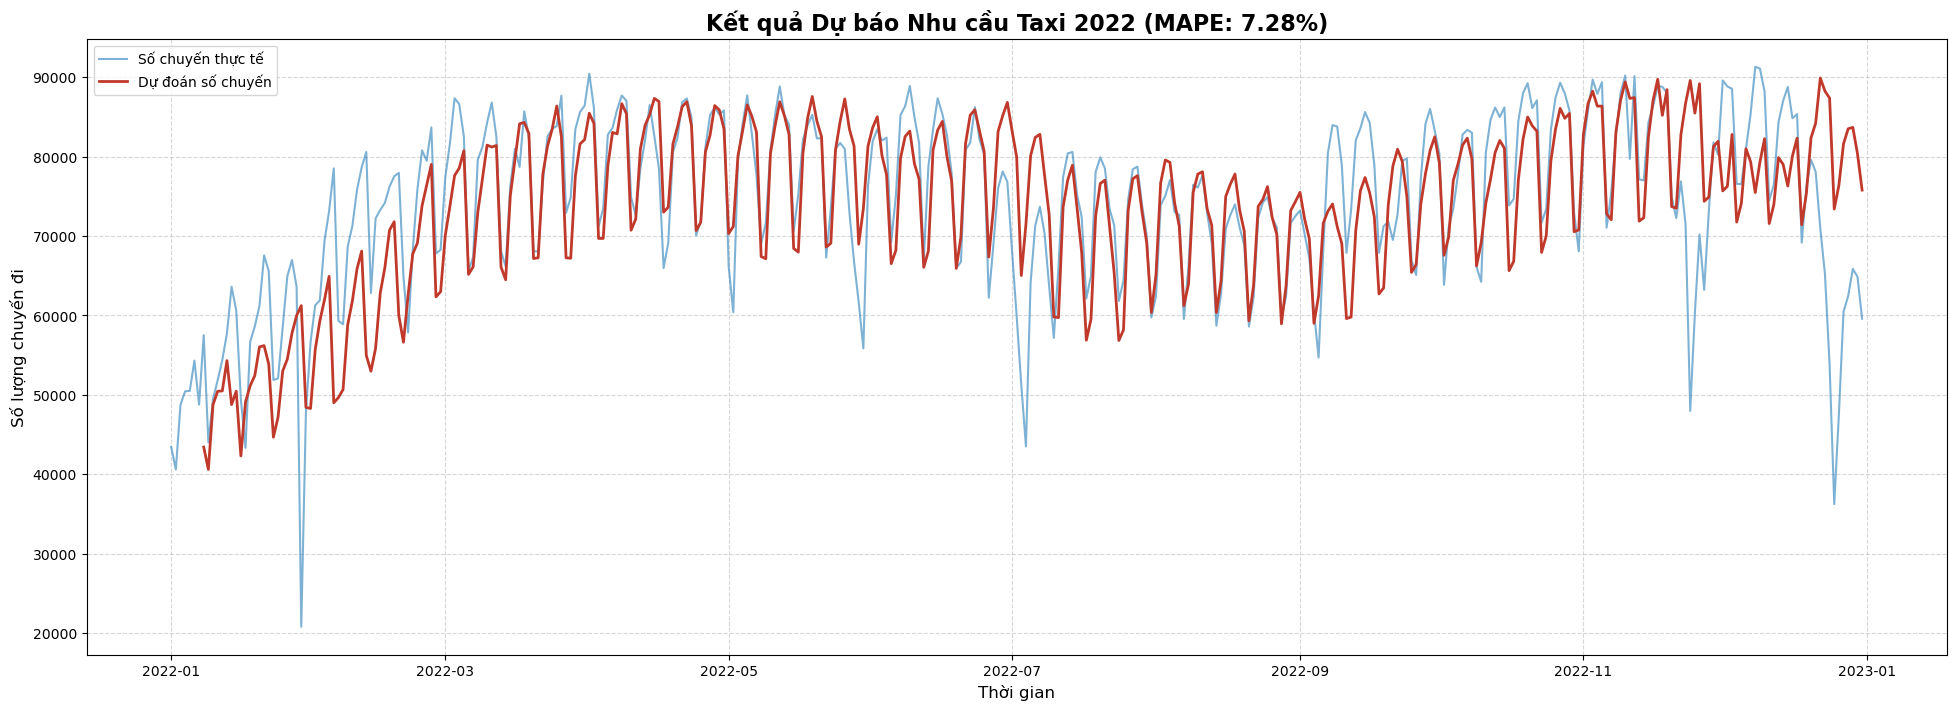

In [30]:
# Vẽ biểu đồ so sánh
plt.figure(figsize=(24, 8))

sns.lineplot(
    data = df_cp_daily,
    x = df_cp_daily.index,
    y = 'total_trips',
    label = 'Số chuyến thực tế',
    color = '#2980b9',
    alpha = 0.6
)

sns.lineplot(
    data = df_cp_daily,
    x = df_cp_daily.index,
    y = 'prediction',
    label = 'Dự đoán số chuyến',
    color = '#c0392b',
    linewidth = 2
)


plt.title(f'Kết quả Dự báo Nhu cầu Taxi 2022 (MAPE: {mape:.2f}%)', fontsize=16, fontweight='bold')
plt.ylabel('Số lượng chuyến đi', fontsize=12)
plt.xlabel('Thời gian', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# 29/01 (194%): Bão tuyết Kenan (Bất khả kháng).
# 25/12 (102%) & 24/12 (62%): Lễ Giáng Sinh & đêm Giáng Sinh.
# 24/11 (86%): Lễ Tạ Ơn (Thanksgiving).
# 04/07 (64%): Lễ Độc Lập Mỹ (Independence Day).
# 26/12 (60%): Nghỉ bù Giáng Sinh (Boxing Day observed)